2.Build a Decision Tree Classifier to help a counsellor predict whether a student will be admitted to a foreign university based on GRE, TOEFL, GPA, and other academic indicators.
Dataset: Graduate Admissions
Tasks:
1. Apply data pre-processing (Label Encoding, Transformation if required).
2. Perform Train-Test Split on the dataset.
3. Implement Decision Tree Classifier.
4. Evaluate model using appropriate performance metrics (Accuracy, Precision, Recall, etc.).

In [ ]:
#helloooo guys add preprocessing step alsoooo
import pandas as pd


In [ ]:
df = pd.read_csv('Admission_Predict - Admission_Predict.csv')
df.head(5)

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,1,337,118,4,4.5,4.5,9.65,1,0.92
1,2,324,107,4,4.0,4.5,8.87,1,0.76
2,3,316,104,3,3.0,3.5,8.00,1,0.72
3,4,322,110,3,3.5,2.5,8.67,1,0.80
4,5,314,103,2,2.0,3.0,8.21,0,0.65


In [ ]:
df.isnull()

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit
0,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...
395,False,False,False,False,False,False,False,False,False
396,False,False,False,False,False,False,False,False,False
397,False,False,False,False,False,False,False,False,False
398,False,False,False,False,False,False,False,False,False


In [ ]:
df.isnull().sum()

,0
Serial No.,0
GRE Score,0
TOEFL Score,0
University Rating,0
SOP,0
LOR,0
CGPA,0
Research,0
Chance of Admit,0


In [ ]:
print(list(df.columns))

['Serial No.', 'GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [ ]:
df.shape

(400, 8)

In [ ]:
df.columns = df.columns.str.strip()

In [ ]:
print(list(df.columns))

['GRE Score', 'TOEFL Score', 'University Rating', 'SOP', 'LOR', 'CGPA', 'Research', 'Chance of Admit']


In [ ]:
df.shape

(400, 8)

In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Chance of Admit'] = le.fit_transform(df['Chance of Admit'])

# ['<=50K' '>50K']


In [ ]:
print(le.classes_)

[0.34 0.36 0.38 0.39 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51
 0.52 0.53 0.54 0.55 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65
 0.66 0.67 0.68 0.69 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79
 0.8  0.81 0.82 0.83 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93
 0.94 0.95 0.96 0.97]


In [ ]:
# converted chance of admit into binrary 0/ 1
df['Admit'] = (df['Chance of Admit'] >= 0.8).astype(int)
df

,Serial No.,GRE Score,TOEFL Score,University Rating,SOP,LOR,CGPA,Research,Chance of Admit,Admit
0,1,337,118,4,4.5,4.5,9.65,1,54,1
1,2,324,107,4,4.0,4.5,8.87,1,38,1
2,3,316,104,3,3.0,3.5,8.00,1,34,1
3,4,322,110,3,3.5,2.5,8.67,1,42,1
4,5,314,103,2,2.0,3.0,8.21,0,27,1
...,...,...,...,...,...,...,...,...,...,...
395,396,324,110,3,3.5,3.5,9.04,1,44,1
396,397,325,107,3,3.0,3.5,9.11,1,46,1
397,398,330,116,4,5.0,4.5,9.45,1,53,1
398,399,312,103,3,3.5,4.0,8.78,0,29,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Admit'] = le.fit_transform(df['Admit'])

In [ ]:
print(le.classes_)

[0 1]


<Axes: ylabel='Frequency'>

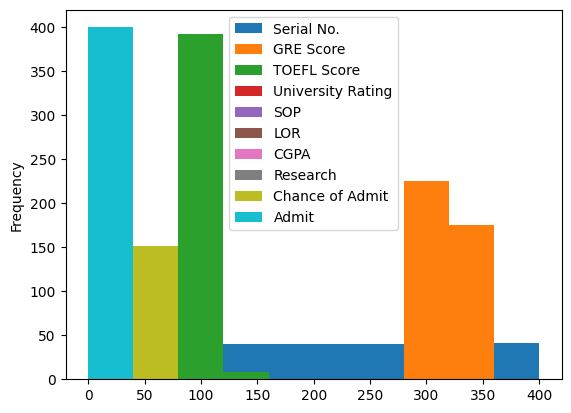

In [ ]:
df.plot.hist()

<Axes: xlabel='SOP', ylabel='Admit'>

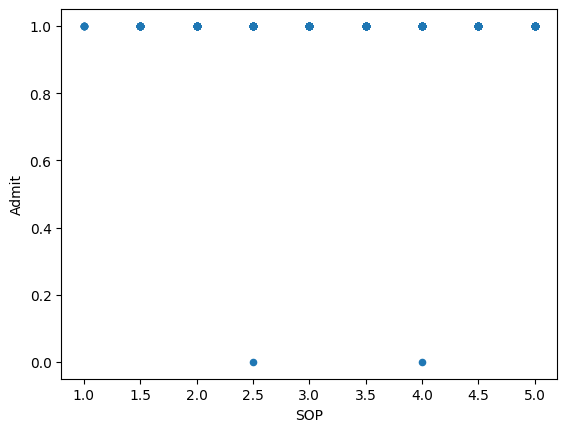

In [ ]:
df.plot(x="SOP", y="Admit",kind="scatter")

In [ ]:
x=df.drop("Admit",axis =1)
y =df["Admit"]

In [ ]:
print("x_shape",x.shape)
print("y_shape",y.shape)

x_shape (400, 9)
y_shape (400,)


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test =train_test_split(x,y,test_size =0.2,random_state=42)

print("train_size of X",X_train.shape)#training
print("train_size of X",X_test.shape)#testing
print("train_size of X",y_train.shape)
print("train_size of X",y_test.shape)


train_size of X (320, 9)
train_size of X (80, 9)
train_size of X (320,)
train_size of X (80,)


In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
model_dt = DecisionTreeClassifier(random_state =1)


In [ ]:
model_dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=1)

In [ ]:
from sklearn.metrics import classification_report,ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

In [ ]:
y_pred_dt=model_dt.predict(X_test)

<Figure size 2000x1000 with 0 Axes>

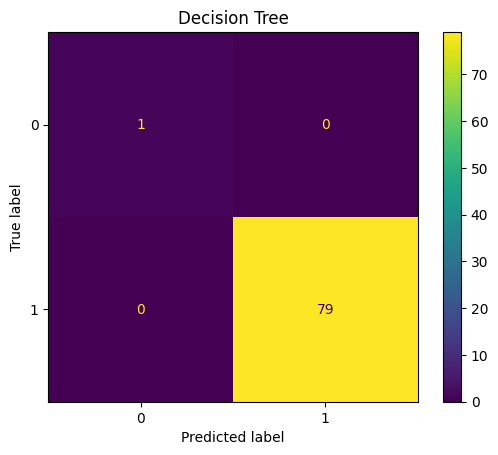

              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00        79

    accuracy                           1.00        80
   macro avg       1.00      1.00      1.00        80
weighted avg       1.00      1.00      1.00        80



In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(20,10))
ConfusionMatrixDisplay.from_predictions(y_test,y_pred_dt)
plt.title("Decision Tree")
plt.show()
print(classification_report (y_test,y_pred_dt))

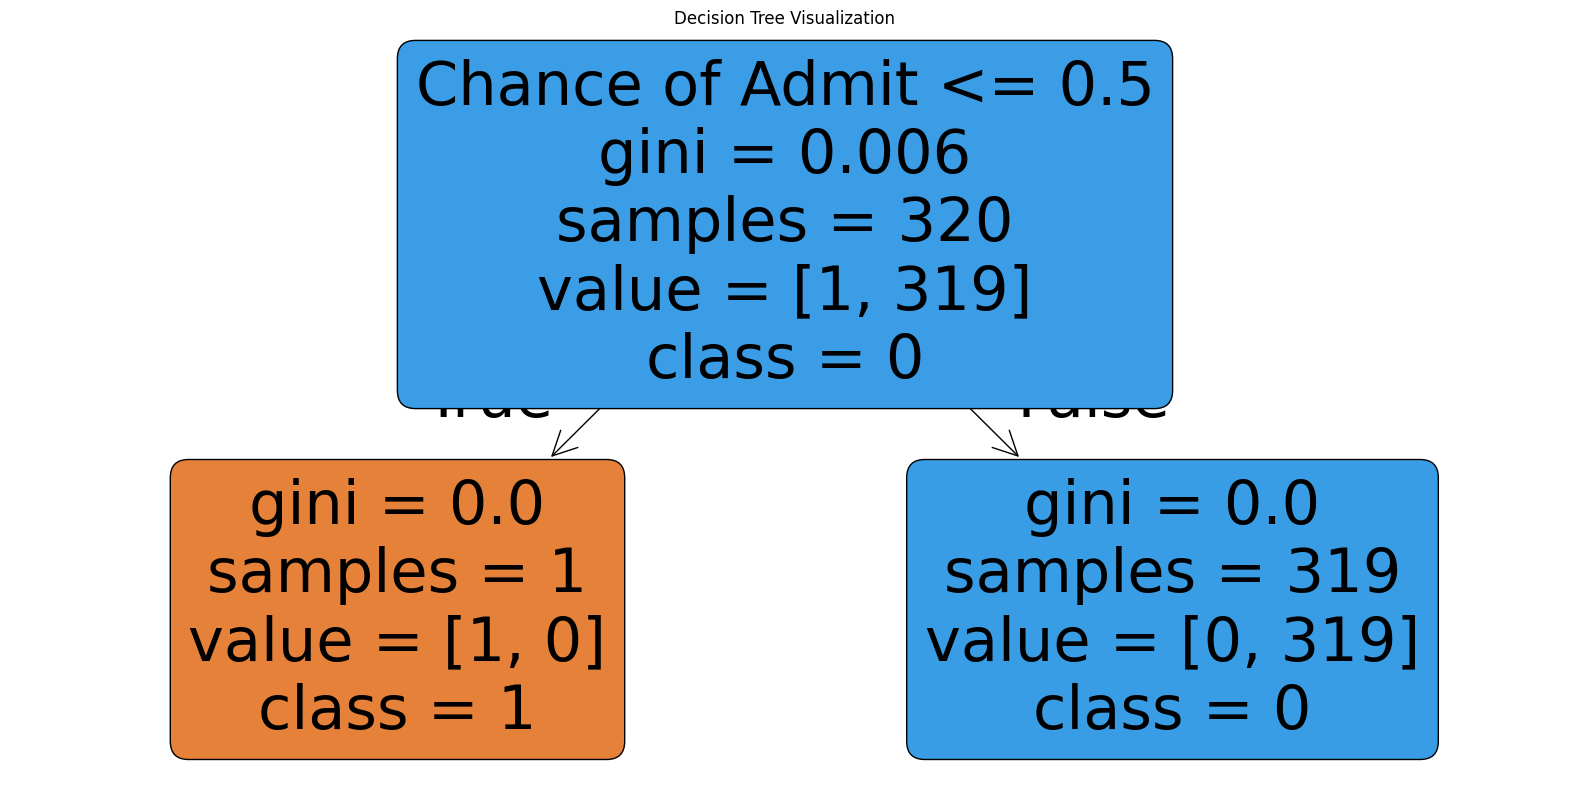

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
import numpy as np
import matplotlib.pyplot as plt

dt = DecisionTreeClassifier(random_state=42, max_depth=4)
dt.fit(X_train, y_train)

plt.figure(figsize=(20,10))
# use the feature names from the training features (X_train). There is no 'y' column in df.
feature_names = X_train.columns
# use the classes learned by the classifier
class_names = y.unique().astype(str)
plot_tree(dt, filled=True, feature_names=feature_names, class_names=class_names,rounded=True)
plt.title("Decision Tree Visualization")
plt.show()


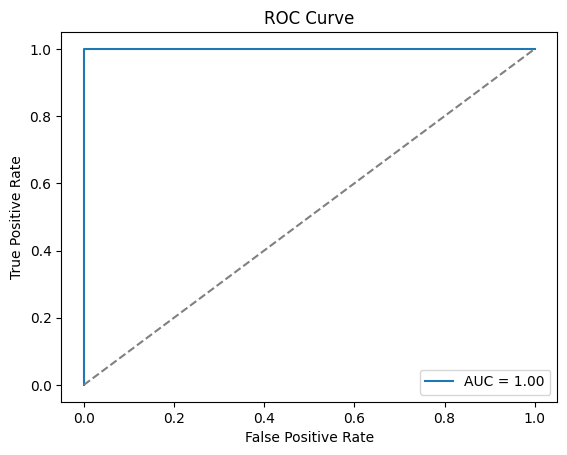

In [ ]:

from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities for positive class
y_prob = model_dt.predict_proba(X_test)[:, 1]

# Compute ROC curve and AUC
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1], [0,1], '--', color='gray')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()